In [1]:
import os, sys
import numpy as np
import pandas as pd
import clip
from glob import glob
import torch
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root)
from utils import utils,models
from PIL import Image

In [2]:
device = utils.get_device()
print(f"Using device: {device}")
batch_size = 64

Using device: mps


In [3]:
model_name = "ViT-L/14"
model, preprocess = utils.load_model(model_name, device)

In [4]:
dataset_dir = '../dataset'
images_dir = f'{dataset_dir}/yfcc100m_50k'
image_paths = glob(os.path.join(images_dir, '*'))

In [5]:
image_paths[:5]

['../dataset/yfcc100m_50k/11349342205.jpg',
 '../dataset/yfcc100m_50k/515729231.jpg',
 '../dataset/yfcc100m_50k/6634420855.jpg',
 '../dataset/yfcc100m_50k/4552772705.jpg',
 '../dataset/yfcc100m_50k/10609770215.jpg']

In [6]:
image_embeddings = np.load("../artifacts/ViT-L-14_embeddings_pool_images.npy")

In [7]:
def encode_texts(texts, model, device, batch_size=32):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            tokens = clip.tokenize(batch, truncate=True).to(device)

            emb = model.encode_text(tokens)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings).astype("float32")

In [8]:
def retrieve_candidates(query, model, device, image_embeddings, image_paths, top_k=10):

    query_emb = encode_texts([query], model, device)[0]

    query_emb = query_emb / np.linalg.norm(query_emb)

    scores = image_embeddings @ query_emb

    indices = np.argsort(-scores)[:top_k]

    candidates = []
    for idx in indices:
        idx = int(idx)

        candidates.append({
            "idx": idx,
            "image_path": image_paths[idx],
            "clip_score": float(scores[idx]),
            "image_emb": image_embeddings[idx]
        })

    return candidates

In [9]:
def show_top_k_images(paths, indices, k=10):
    for i in indices[:k]:
        candidate = paths[i]
        img = Image.open(candidate)
        display(img)

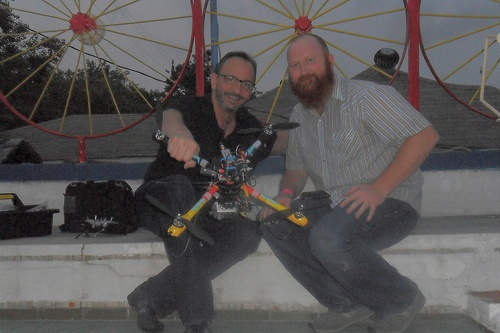

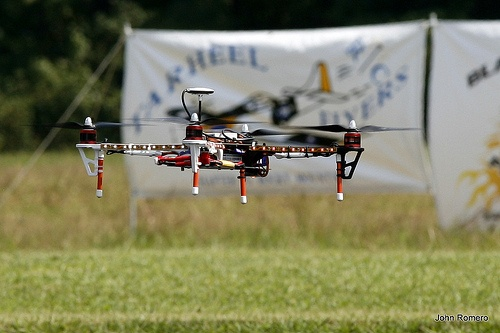

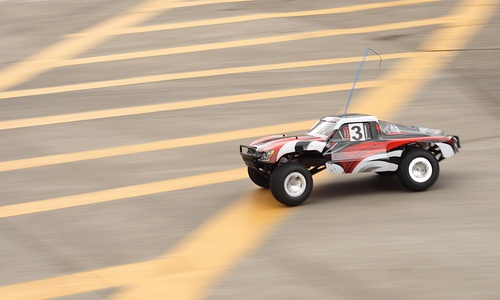

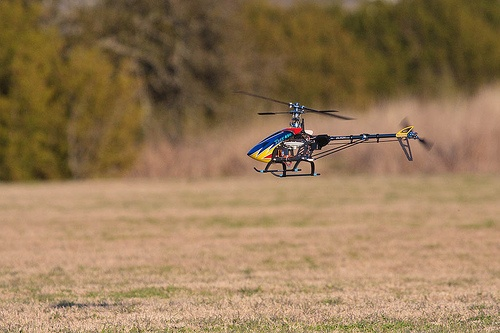

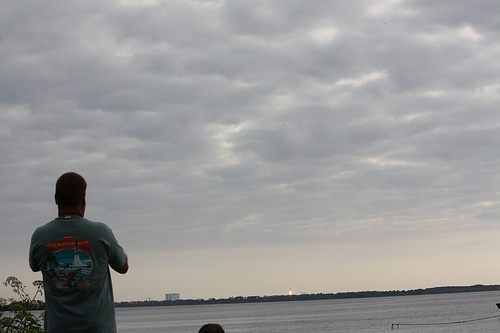

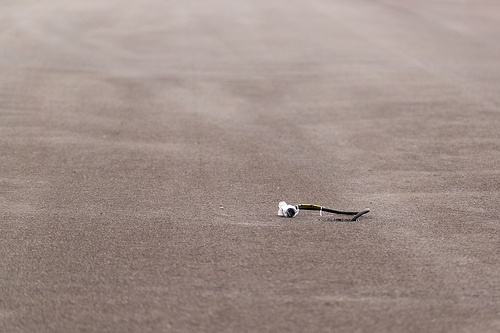

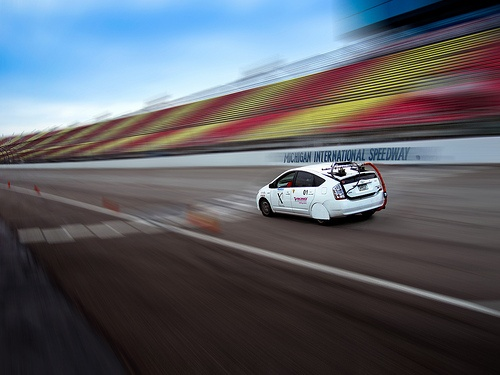

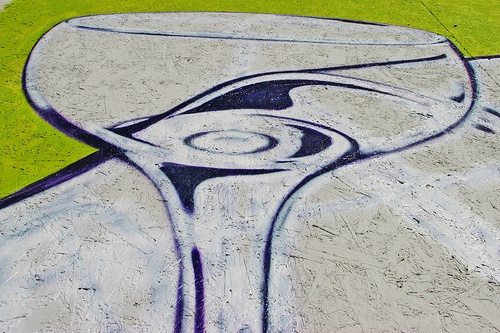

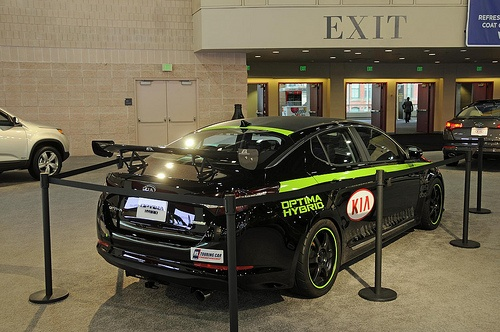

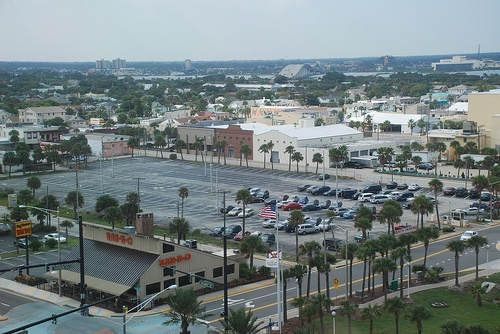

In [14]:
query = "Drone racing takes a whirl in Daytona Stadium"
candidates = retrieve_candidates(query, model, device, image_embeddings, image_paths)
candidates_indices = [candidate['idx'] for candidate in candidates]
show_top_k_images(image_paths,candidates_indices,10)

In [12]:
len(list(glob(os.path.join("/Users/imranabbas/Documents/DLP/newsimages/dataset/yfcc100m_50k", '*'))))

50000

In [12]:
%pip install datasets requests pillow tqdm

Python(77369) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.19-py311-none-any.whl.metadata (7.5 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohttp-3.13.5-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.1 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (20 kB)
  Using cached multidict-6.7.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (5.3 kB)
  Using cached yarl-1.23.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (79 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 2.1 MB/s  0:00:00m0:00:01
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached multiprocess-0.70.19-py311-none-any.whl (144 kB)
Using cached aiohttp-3.13.5-cp311-cp311-macosx_11_0_arm64.whl (501 kB)
Using cached m

In [2]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

import requests
from io import BytesIO
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from concurrent.futures import ThreadPoolExecutor, as_completed


def sample_and_download_pd12m(
    target_count=20,
    output_dir="pd12m_sample",
    max_workers=4,
):

    os.makedirs(output_dir, exist_ok=True)

    print("Loading streaming dataset...")

    total_dataset_size = 12_400_000
    step_interval = total_dataset_size // target_count

    dataset_stream = load_dataset(
        "Spawning/PD12M",
        split="train",
        streaming=True,
    )

    selected_metadata = []

    for idx, row in enumerate(dataset_stream):

        if len(selected_metadata) >= target_count:
            break

        if idx % step_interval == 0:

            url = row.get("url")
            img_id = row.get("id")

            if url and img_id:

                selected_metadata.append(
                    {
                        "id": str(img_id),
                        "url": url,
                        "caption": row.get("caption", ""),
                    }
                )

        if idx % 100000 == 0:
            print(
                f"Scanned: {idx:,} | "
                f"Selected: {len(selected_metadata)}"
            )

    print(f"\nCollected {len(selected_metadata)} rows.")

    def download_image(item):

        try:

            img_id = item["id"]
            url = item["url"]
            caption = item["caption"]

            ext = (
                url.split(".")[-1]
                .split("?")[0]
                .lower()
            )

            if ext not in ["jpg", "jpeg", "png", "webp"]:
                ext = "jpg"

            img_path = os.path.join(
                output_dir,
                f"{img_id}.{ext}"
            )

            txt_path = os.path.join(
                output_dir,
                f"{img_id}.txt"
            )

            if os.path.exists(img_path):
                return True

            response = requests.get(
                url,
                timeout=10,
                headers={
                    "User-Agent": "Mozilla/5.0"
                }
            )

            if response.status_code != 200:
                print(
                    f"[HTTP {response.status_code}] {url}"
                )
                return False

            try:
                img = Image.open(
                    BytesIO(response.content)
                )
                img.load()

            except Exception as e:
                print(f"[INVALID IMAGE] {e}")
                return False

            with open(img_path, "wb") as f:
                f.write(response.content)

            with open(
                txt_path,
                "w",
                encoding="utf-8"
            ) as f:
                f.write(caption)

            return True

        except Exception as e:

            print(f"[FAILED] {e}")
            return False

    print("\nDownloading images...\n")

    success_count = 0

    with ThreadPoolExecutor(
        max_workers=max_workers
    ) as executor:

        futures = [
            executor.submit(download_image, item)
            for item in selected_metadata
        ]

        for future in tqdm(
            as_completed(futures),
            total=len(futures),
        ):

            if future.result():
                success_count += 1

    print(
        f"\nDownloaded "
        f"{success_count}/{len(selected_metadata)}"
    )


if __name__ == "__main__":

    sample_and_download_pd12m(
        target_count=20,
        output_dir="pd12m_sample",
        max_workers=4,
    )

/Users/imranabbas/Documents/DLP/newsimages/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading streaming dataset...
Scanned: 0 | Selected: 1
Scanned: 100,000 | Selected: 1
Scanned: 200,000 | Selected: 1
Scanned: 300,000 | Selected: 1
Scanned: 400,000 | Selected: 1
Scanned: 500,000 | Selected: 1
Scanned: 600,000 | Selected: 1
Scanned: 700,000 | Selected: 2
Scanned: 800,000 | Selected: 2
Scanned: 900,000 | Selected: 2
Scanned: 1,000,000 | Selected: 2
Scanned: 1,100,000 | Selected: 2
Scanned: 1,200,000 | Selected: 2
Scanned: 1,300,000 | Selected: 3
Scanned: 1,400,000 | Selected: 3
Scanned: 1,500,000 | Selected: 3
Scanned: 1,600,000 | Selected: 3
Scanned: 1,700,000 | Selected: 3
Scanned: 1,800,000 | Selected: 3
Scanned: 1,900,000 | Selected: 4
Scanned: 2,000,000 | Selected: 4
Scanned: 2,100,000 | Selected: 4
Scanned: 2,200,000 | Selected: 4
Scanned: 2,300,000 | Selected: 4
Scanned: 2,400,000 | Selected: 4
Scanned: 2,500,000 | Selected: 5
Scanned: 2,600,000 | Selected: 5
Scanned: 2,700,000 | Selected: 5
Scanned: 2,800,000 | Selected: 5
Scanned: 2,900,000 | Selected: 5
Scanned

KeyboardInterrupt: 